<a href="https://colab.research.google.com/github/sergiomora03/AdvancedTopicsAnalytics/blob/main/E6-NeuralNetworksinPyTorchforNLP/E5_NeuralNetworksPyTorchNLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Use keras framework to solve the below exercises.


In [1]:
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [2]:
import numpy as np
import keras
import pandas as pd
import string
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from nltk.corpus import stopwords

## 5.1 Predict rating of a movie using Keras

**Exercise:** Use keras framework to predict rating.

In [3]:
dataTraining = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0)

In [4]:
plots = dataTraining['plot']
y = (dataTraining['rating'] >= dataTraining['rating'].mean()).astype(int)

In [5]:
plots

,plot
3107,most is the story of a single father who takes...
900,a serial killer decides to teach the secrets o...
6724,"in sweden , a female blackmailer with a disfi..."
4704,"in a friday afternoon in new york , the presi..."
2582,"in los angeles , the editor of a publishing h..."
...,...
8417,""" our marriage , their wedding . "" it ' s l..."
1592,"the wandering barbarian , conan , alongside ..."
1723,"like a tale spun by scheherazade , kismet fol..."
7605,"mrs . brisby , a widowed mouse , lives in a..."


In [6]:
y

,rating
3107,1
900,0
6724,1
4704,1
2582,1
...,...
8417,0
1592,0
1723,0
7605,1


## Data Precosessing

- Remove stopwords
- Lowercase
- split the text in words
- pad_sequences

In [7]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = ''.join([word for word in text if word not in string.punctuation])
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

In [8]:
cleaned_plots = plots.apply(preprocess_text)
print(cleaned_plots[0])
print(plots[0])

major benson winifred payne discharged marines payne killin machine wars world longer fought battlefield career marine idea civilian commander finds job commanding officer local school jrotc program bunch ragtag losers hope using teaching tools live grenades real bullets payne starts instill corp hope payne recalled fight bosnia leave corp started believe find killin much livin
major benson winifred payne is being discharged from the marines .  payne is a killin '  machine ,  but the wars of the world are no longer fought on the battlefield .  a career marine ,  he has no idea what to do as a civilian ,  so his commander finds him a job  -  commanding officer of a local school ' s jrotc program ,  a bunch or ragtag losers with no hope .  using such teaching tools as live grenades and real bullets ,  payne starts to instill the corp with some hope .  but when payne is recalled to fight in bosnia ,  will he leave the corp that has just started to believe in him ,  or will he find out tha

In [9]:
X = cleaned_plots.tolist()
# For vocabulary only the intersec characters is used to avoid issues with data collection
voc = set(''.join(X))
vocabulary = {x: idx + 1 for idx, x in enumerate(set(voc))}

In [13]:
# Max len
maxlen = 150

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(cleaned_plots)
sequences = tokenizer.texts_to_sequences(cleaned_plots)
# OOV tokens get index 1, which is < 10000, so no problem
X = pad_sequences(sequences, maxlen=maxlen, padding='post', truncating='post')


y = np.array(y)

## Build Model

Create a neural network to predict the rating of a movie, calculate the testing set accuracy.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split

class TextDataset(Dataset):
    def __init__(self, X, y):
        # X: np.array, y: np.array
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TextDataset(X_train, y_train)
test_dataset  = TextDataset(X_test, y_test)

# Dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size)

In [16]:
class SimpleLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        # x shape (batch, seq)
        emb = self.embedding(x)
        _, (h, _) = self.lstm(emb)
        out = self.fc(h[-1])
        return self.sigmoid(out).squeeze(1)

In [18]:
vocab_size = int(np.max(X)) + 1  # tokenizer.word_index es 1-indexed

# Instantiate
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleLSTMClassifier(vocab_size=vocab_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

In [19]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
num_epochs = 10

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss, running_correct, running_total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        running_correct += ((preds > 0.5).float() == yb).sum().item()
        running_total += xb.shape[0]

    train_losses.append(running_loss / running_total)
    train_accuracies.append(running_correct / running_total)

    # Validation (test)
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_loss += loss.item() * xb.size(0)
            val_correct += ((preds > 0.5).float() == yb).sum().item()
            val_total += xb.shape[0]

    val_losses.append(val_loss / val_total)
    val_accuracies.append(val_correct / val_total)

    print(f"Epoch {epoch+1}: Train Loss = {train_losses[-1]:.4f}, Val Loss = {val_losses[-1]:.4f}, "
          f"Train Acc = {train_accuracies[-1]:.4f}, Val Acc = {val_accuracies[-1]:.4f}")

Epoch 1: Train Loss = 0.6927, Val Loss = 0.6893, Train Acc = 0.5141, Val Acc = 0.5472
Epoch 2: Train Loss = 0.6890, Val Loss = 0.6885, Train Acc = 0.5239, Val Acc = 0.5478
Epoch 3: Train Loss = 0.6828, Val Loss = 0.6890, Train Acc = 0.5203, Val Acc = 0.5446
Epoch 4: Train Loss = 0.6753, Val Loss = 0.6965, Train Acc = 0.5350, Val Acc = 0.4718
Epoch 5: Train Loss = 0.6667, Val Loss = 0.7033, Train Acc = 0.5328, Val Acc = 0.4788
Epoch 6: Train Loss = 0.6584, Val Loss = 0.7049, Train Acc = 0.5334, Val Acc = 0.5446
Epoch 7: Train Loss = 0.6504, Val Loss = 0.7078, Train Acc = 0.5374, Val Acc = 0.4902
Epoch 8: Train Loss = 0.6431, Val Loss = 0.7258, Train Acc = 0.5408, Val Acc = 0.5484
Epoch 9: Train Loss = 0.6565, Val Loss = 0.7054, Train Acc = 0.5554, Val Acc = 0.4794
Epoch 10: Train Loss = 0.6608, Val Loss = 0.7044, Train Acc = 0.5421, Val Acc = 0.5415


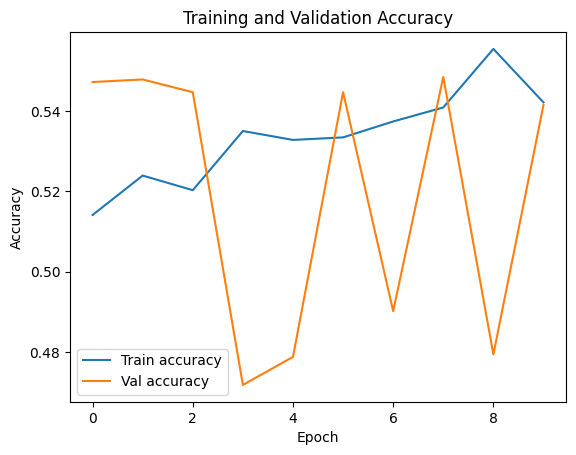

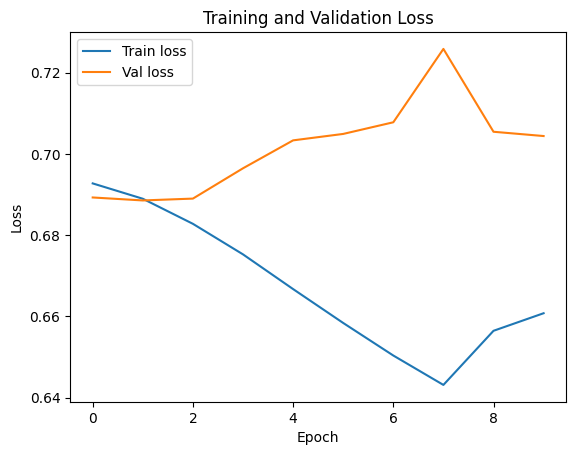

In [20]:
import matplotlib.pyplot as plt

plt.plot(train_accuracies, label='Train accuracy')
plt.plot(val_accuracies, label='Val accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

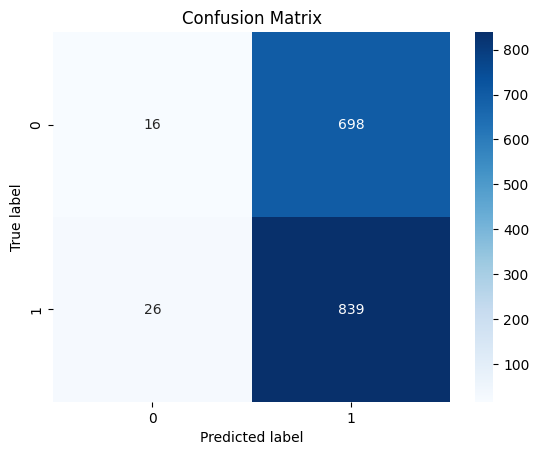

              precision    recall  f1-score   support

           0       0.38      0.02      0.04       714
           1       0.55      0.97      0.70       865

    accuracy                           0.54      1579
   macro avg       0.46      0.50      0.37      1579
weighted avg       0.47      0.54      0.40      1579

Rating real: 1, predicción: 1
---
Rating real: 1, predicción: 1
---
Rating real: 1, predicción: 1
---
Rating real: 1, predicción: 1
---
Rating real: 0, predicción: 1
---
Rating real: 1, predicción: 1
---
Rating real: 0, predicción: 1
---
Rating real: 1, predicción: 1
---
Rating real: 1, predicción: 1
---
Rating real: 0, predicción: 1
---
Rating real: 1, predicción: 1
---
Rating real: 0, predicción: 1
---
Rating real: 1, predicción: 1
---
Rating real: 1, predicción: 1
---
Rating real: 0, predicción: 1
---
Rating real: 1, predicción: 1
---
Rating real: 1, predicción: 1
---
Rating real: 0, predicción: 1
---
Rating real: 1, predicción: 1
---
Rating real: 1, predicción:

In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Collect all preds and true labels
all_preds = []
all_true = []

model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = (model(xb) > 0.5).long().cpu().numpy()
        all_preds.extend(preds.flatten())
        all_true.extend(yb.long().cpu().numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

# Confusion matrix
cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print(classification_report(all_true, all_preds))

# Show some predictions
for i in range(min(20, len(all_preds))):
    print(f"Rating real: {all_true[i]}, predicción: {all_preds[i]}")
    print('---')